# Export urban and rural temperatures
- This script is used to export urban and rural ground/air temperature.
- Simulations: CNTL, TranAlbe

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import geopandas as gpd
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from scipy import stats
import string
from scipy.stats import gaussian_kde
import os
home_path = '/gws/ssde/j25a/duicv/yuansun/'
project_path = f'{home_path}0_wrf-cstm_GM-HK/'

In [3]:
date_start = '05-29'
date_end = '08-27'
year = 2039

start = datetime.strptime(f"{year}-{date_start}", "%Y-%m-%d")
end = datetime.strptime(f"{year}-{date_end}", "%Y-%m-%d")
dates = []
current_date = start
while current_date <= end:
    dates.append(current_date.strftime("%Y-%m-%d"))
    current_date += timedelta(days=5)

print(dates)

['2039-05-29', '2039-06-03', '2039-06-08', '2039-06-13', '2039-06-18', '2039-06-23', '2039-06-28', '2039-07-03', '2039-07-08', '2039-07-13', '2039-07-18', '2039-07-23', '2039-07-28', '2039-08-02', '2039-08-07', '2039-08-12', '2039-08-17', '2039-08-22', '2039-08-27']


In [4]:
df_heatwave_identify_35 = pd.read_csv(f'{home_path}0_wrf-cstm_GM-HK/output_analysis/heatwave_identify/data_for_figure/HK_heatwave_events_35_cntl_urban_rural.csv')
df_heatwave_identify_35_tsau = df_heatwave_identify_35[df_heatwave_identify_35['var']=='TSA_U'].copy()
df_heatwave_identify_35_tsau['start'] = pd.to_datetime(df_heatwave_identify_35_tsau['start'])
df_heatwave_identify_35_tsau['end'] = pd.to_datetime(df_heatwave_identify_35_tsau['end'])
df_heatwave_identify_35_tsau_2039 = df_heatwave_identify_35_tsau[df_heatwave_identify_35_tsau['start'].dt.year==2039].copy()
df_heatwave_identify_35_tsau_2039

,start,end,duration,var
30,2039-05-25,2039-05-27,3,TSA_U
31,2039-06-29,2039-07-07,9,TSA_U
32,2039-07-11,2039-07-21,11,TSA_U
33,2039-08-04,2039-08-09,6,TSA_U
34,2039-08-11,2039-08-22,12,TSA_U
35,2039-08-24,2039-08-29,6,TSA_U
36,2039-08-31,2039-09-02,3,TSA_U
37,2039-09-17,2039-09-19,3,TSA_U


In [5]:
heatwave_dates = []
df_hw = df_heatwave_identify_35_tsau_2039.copy()
for _, row in df_hw.iterrows():
    dates_range = pd.date_range(row['start'], row['end'], freq='D')
    heatwave_dates.extend(dates_range)
heatwave_dates = pd.to_datetime(sorted(set(heatwave_dates)))
heatwave_dates  

DatetimeIndex(['2039-05-25', '2039-05-26', '2039-05-27', '2039-06-29',
               '2039-06-30', '2039-07-01', '2039-07-02', '2039-07-03',
               '2039-07-04', '2039-07-05', '2039-07-06', '2039-07-07',
               '2039-07-11', '2039-07-12', '2039-07-13', '2039-07-14',
               '2039-07-15', '2039-07-16', '2039-07-17', '2039-07-18',
               '2039-07-19', '2039-07-20', '2039-07-21', '2039-08-04',
               '2039-08-05', '2039-08-06', '2039-08-07', '2039-08-08',
               '2039-08-09', '2039-08-11', '2039-08-12', '2039-08-13',
               '2039-08-14', '2039-08-15', '2039-08-16', '2039-08-17',
               '2039-08-18', '2039-08-19', '2039-08-20', '2039-08-21',
               '2039-08-22', '2039-08-24', '2039-08-25', '2039-08-26',
               '2039-08-27', '2039-08-28', '2039-08-29', '2039-08-31',
               '2039-09-01', '2039-09-02', '2039-09-17', '2039-09-18',
               '2039-09-19'],
              dtype='datetime64[ns]', freq=None

In [6]:
land_var_list = ['TG_R', 'TSA_R', 'TG_U', 'TSA_U']
final_list = []
for date in dates:
    cntl_filename = f'{home_path}0_wrf-cstm_GM-HK/runs/TranUrbAlb_HK/runs/d04_cntl/archive_ctsm/lnd/cntl_albe5.clm2.h0.{date}-03600.nc'
    tran_albe_filename = f'{home_path}0_wrf-cstm_GM-HK/runs/TranUrbAlb_HK/runs/d04_tran_albe/archive_ctsm/lnd/tran_albe5.clm2.h0.{date}-03600.nc'
    ds_cntl = xr.open_dataset(cntl_filename)
    ds_tran_albe = xr.open_dataset(tran_albe_filename)
    jja_hw_dict = {var: [] for var in land_var_list}
    for land_var in land_var_list:
        ds_cntl_var = ds_cntl[land_var].isel(time=np.arange(5, 120, 24))
        ds_tran_albe_var = ds_tran_albe[land_var].isel(time=np.arange(5, 120, 24))
        delta = ds_tran_albe_var - ds_cntl_var
        if date == f'{year}-{date_start}':
            delta_jja = delta.sel(time=delta['time'].dt.month ==6)
        else:
            delta_jja = delta
        delta_hw = delta_jja.sel(time=delta_jja['time'].dt.floor('D').isin(heatwave_dates))    
        jja_hw_dict[land_var].append(delta_hw)    
    final_list.append(jja_hw_dict)    
final_hw_mean_dict = {var: xr.concat([d[var][0] for d in final_list], dim='time').mean(dim='time')
                      for var in land_var_list}
for var, mean_val in final_hw_mean_dict.items():
    output_filename = f'./data_for_figure/changes_{var}_{year}_JJA.nc'
    if os.path.exists(output_filename):
        os.remove(output_filename)
    mean_val.to_netcdf(output_filename)

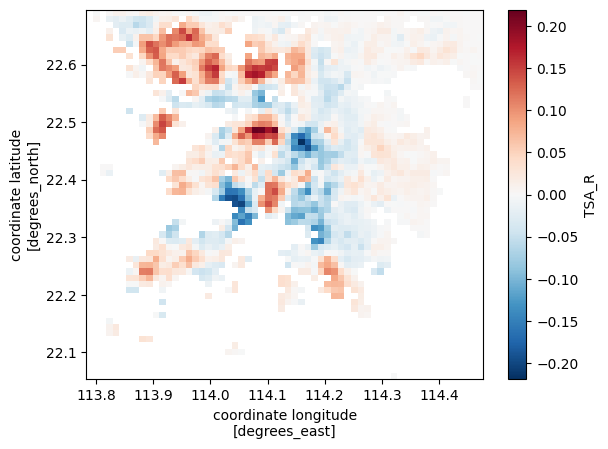

In [9]:
mean_val.plot()

In [7]:
sig_dict = {}
for var in land_var_list:
    data = xr.concat([d[var][0] for d in final_list], dim='time')
    # effective sample size per grid cell
    n_eff = data.count(dim='time')
    # mask invalid cells early
    data_valid = data.where(n_eff > 1)
    # mean and std
    mean = data_valid.mean(dim='time')
    std = data_valid.std(dim='time')
    # avoid division issues
    valid = (n_eff > 1) & (std > 0)
    # t-stat using n_eff (NOT global n)
    t_stat = xr.where(valid, mean / (std / np.sqrt(n_eff)), np.nan)
    # p-value
    p_value = xr.apply_ufunc(
        lambda t, n: 2 * (1 - stats.t.cdf(np.abs(t), df=n-1)),
        t_stat,
        n_eff,
        vectorize=True
    )
    sig_dict[var] = p_value
for var, p_val in sig_dict.items():
    output_filename = f'./data_for_figure/changes_{var}_{year}_JJA_significance.nc'
    p_val.to_netcdf(output_filename) 

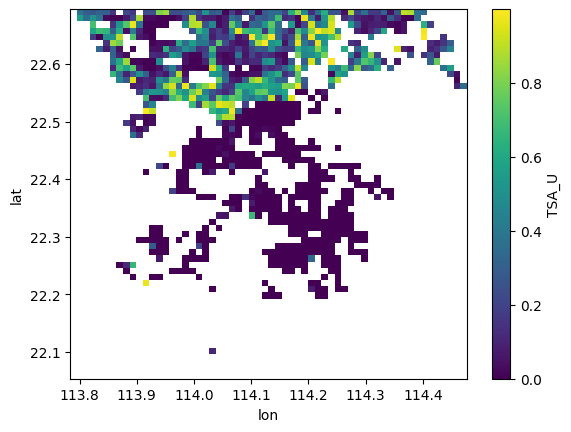

In [11]:
p_val.plot()